In [2]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



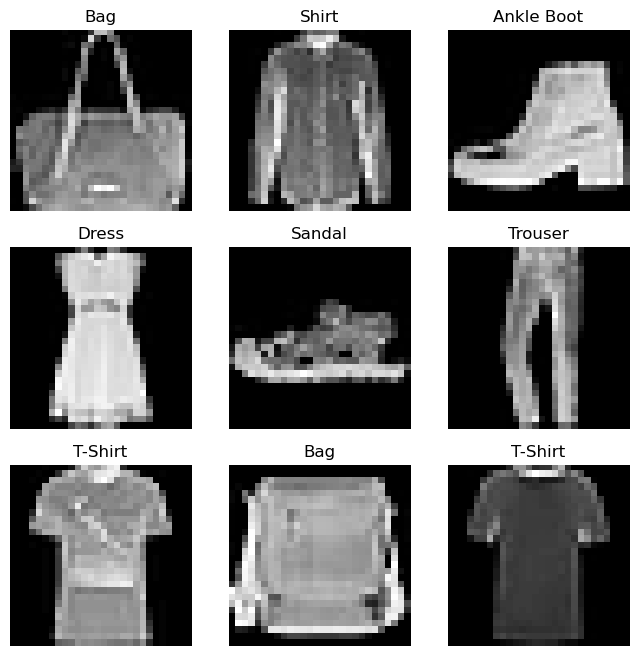

In [3]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}# 先形成一个映射表

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()# 生成随机数
    img, label = training_data[sample_idx] # 取出照片
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
# PyTorch 的做法是： 统一规定图片必须是 [通道, 高, 宽]。
# 灰度图就是 [1, 28, 28]。
# 彩色图就是 [3, 28, 28]。
    plt.imshow(img.squeeze(), cmap="gray")# img.squeeze先压缩一下
plt.show()

In [4]:
import os

In [5]:
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):# 将dataset当作基类
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

# self.img_labels = pd.read_csv(annotations_file) (读账本)
# 意思：调用 pandas 库（缩写为 pd）去读那个 CSV 文件。
# 为什么要现在读？ 因为 CSV 文件很小，一次性读进内存可以极大地加快后面 __getitem__ 查找的速度。
# 结果：self.img_labels 变成了一个类似二维数组的表格对象。
# self.img_dir = img_dir (存)
# 意思：记住图片存在哪个文件夹里。
# 注意：这里没有去读图片，只是记住了路径字符串。就像 C++ 里存了一个 std::string。
# self.transform 和 self.target_transform (领工具)
# 意思：这是两个“预处理钩子（Hooks）”。
# transform：针对图片的加工。比如：把图片从 [0, 255] 缩放到 [0, 1]，或者把图片随机旋转一下。
# target_transform：针对标签的加工。比如：把数字标签转成 One-hot 编码。
# =None：代表默认不加工，原样输出。

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label
# 1. img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
# 字面意思：拼接图片的完整绝对路径。
# 详细拆解：
# self.img_labels.iloc[idx, 0]：去内存里的“账本”表格，翻到第 idx 行，取第 0 列（第一列）。这一列存的是文件名（如 "tshirt_01.jpg"）。
# os.path.join：把文件夹路径（如 "data/images"）和文件名拼起来。
# C++ 类比：类似于 std::string full_path = root_dir + "/" + csv_table[idx].filename;。

# 2. image = decode_image(img_path)
# 字面意思：从硬盘读取并解码图片。
# 详细拆解：
# 调用 torchvision.io 的解码器，顺着刚才拼好的路径找到文件。
# 将二进制的图片文件（JPG/PNG）转成一个 Tensor（张量）。
# C++ 类比：类似于调用 OpenCV 的 cv::imread(full_path)，把文件变成内存里的矩阵。

# 3. label = self.img_labels.iloc[idx, 1]
# 字面意思：获取这张图片的“标准答案”。
# 详细拆解：
# 再次查账本，还是第 idx 行，但这次取第 1 列（第二列）。
# 这一列存的是数字（如 0 代表 T 恤，9 代表靴子）。
# 注意：此时 image 是巨大的矩阵，而 label 只是一个很小的整数。

# 4. if self.transform: 与 image = self.transform(image)
# 字面意思：如果开启了“图片加工”，就加工一下。
# 详细拆解：
# self.transform 相当于一个回调函数指针。
# 如果我们在初始化类时传了 ToTensor()，这里就会把 0-255 的整数像素变成 0.0-1.0 的浮点数。
# C++ 类比：if (callback) image = callback(image);
# 5. if self.target_transform: 与 label = self.target_transform(label)
# 字面意思：如果开启了“标签加工”，就加工一下。
# 详细拆解
# 同样的逻辑，只不过是针对那个数字标签。比如把数字 3 变成一个独热向量（One-hot）。
# 6. return image, label
# 字面意思：把加工好的“题目”和“答案”打包交出去。
# 详细拆解：
# Python 支持返回多个值。实际上它返回了一个 Tuple（元组）。
# 调用者（通常是 DataLoader）拿到这一组数据后，会把它们和其他样本拼在一起送给显卡。

In [6]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)#shuffle=True (随机打乱)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


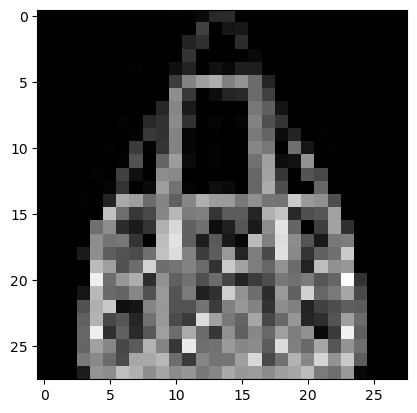

Label: 8


In [7]:
train_features, train_labels = next(iter(train_dataloader))
# 第一步：iter(train_dataloader) (获取迭代器)
# 意思：将 DataLoader 这个“物流车队”变成一个可以被拨动的“传送带”。
# C++ 类比：相当于调用了容器的 begin() 函数
# auto it = train_dataloader.begin(); 
# 第二步：next(...) (拨动开关
# 意思：从传送带上抓取第一个包裹（也就是第一批 Batch）。
# 逻辑：一旦执行 next，DataLoader 内部就会立刻指挥它的“搬运工”去调用 Dataset 64 次（假设 batch_size=64），并把结果打包。
# C++ 类比：相当于执行了 *it（解引用获取当前值）并准备好指向下一个。
# 第三步：train_features, train_labels = ... (解包)
# 意思：把抓到的这个大包裹拆开。
# 结果：
# train_features: 这一车的 64 张图片（4D Tensor）。
# train_labels: 这一车的 64 个答案（1D Tensor）。
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")